In [1]:
# Load Dataset
import os

dataset_path = r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset"

# Cek apakah path valid
if os.path.exists(dataset_path):
    print("Dataset berhasil dimuat.")
else:
    print("Path dataset tidak ditemukan.")

Dataset berhasil dimuat.


In [2]:
# Menampilkan Jumlah Kelas dan Daftar Kelas
classes = [cls for cls in os.listdir(dataset_path)
           if os.path.isdir(os.path.join(dataset_path, cls))]

print("Jumlah kelas:", len(classes))
print("Daftar kelas:")
for cls in classes:
    print("-", cls)

Jumlah kelas: 4
Daftar kelas:
- cataract
- diabetic_retinopathy
- glaucoma
- normal


In [3]:
import pandas as pd

data = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    num_images = len([
        img for img in os.listdir(cls_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])

    data.append({
        "Class": cls,
        "Total Images": num_images
    })

df_class_distribution = pd.DataFrame(data)
df_class_distribution

,Class,Total Images
0,cataract,1038
1,diabetic_retinopathy,1098
2,glaucoma,1007
3,normal,1074


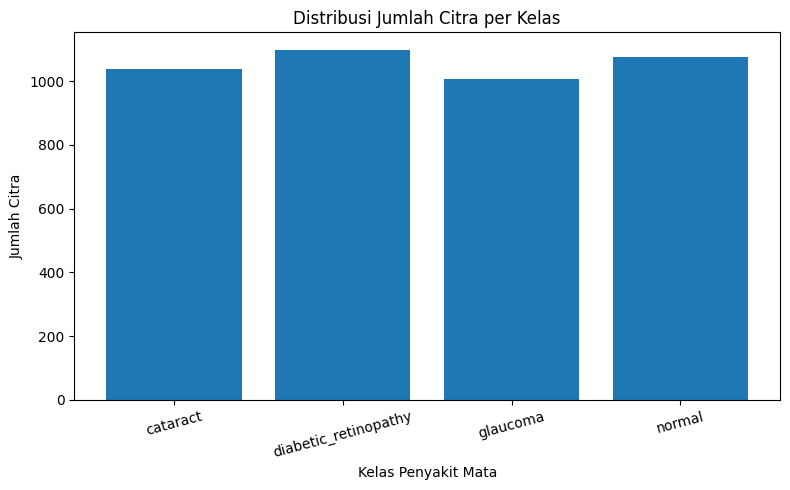

In [4]:
# Visualisasi Distribusi Kelas
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(df_class_distribution["Class"],
        df_class_distribution["Total Images"])
plt.xlabel("Kelas Penyakit Mata")
plt.ylabel("Jumlah Citra")
plt.title("Distribusi Jumlah Citra per Kelas")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

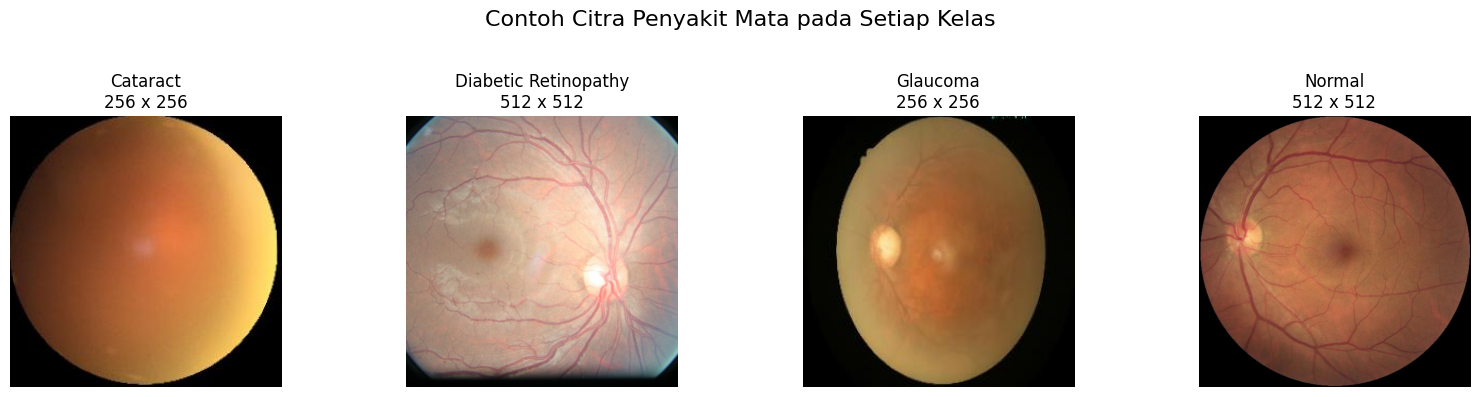

In [5]:
# Visualisasi Sampel Citra + Resolusi + Judul
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(16, 4))

# Judul utama (headline)
plt.suptitle("Contoh Citra Penyakit Mata pada Setiap Kelas", fontsize=16)

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    width, height = img.size

    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.title(f"{cls.replace('_', ' ').title()}\n{width} x {height}")
    plt.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.90])  # biar tidak tabrakan dengan judul utama
plt.show()

In [6]:
# Analisis Ukuran & Resolusi Citra per kelas
from PIL import Image
import pandas as pd
import os

data_sizes = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    print(f"Memproses kelas: {cls}")

    for img_name in os.listdir(cls_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            width, height = img.size

            data_sizes.append({
                "Class": cls,
                "Width": width,
                "Height": height
            })

df_sizes = pd.DataFrame(data_sizes)
df_sizes["Class"].value_counts()

Memproses kelas: cataract
Memproses kelas: diabetic_retinopathy
Memproses kelas: glaucoma
Memproses kelas: normal


Class
diabetic_retinopathy    1098
normal                  1074
cataract                1038
glaucoma                1007
Name: count, dtype: int64

In [7]:
# Tambahkan kolom resolusi (WxH)
df_sizes["Resolution"] = df_sizes["Width"].astype(str) + "x" + df_sizes["Height"].astype(str)

# Hitung resolusi unik per kelas
resolution_per_class = (
    df_sizes
    .groupby(["Class", "Resolution"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Class", "Count"], ascending=[True, False])
)

resolution_per_class.head(20)

,Class,Resolution,Count
2,cataract,256x256,640
4,cataract,512x512,298
3,cataract,2592x1728,76
1,cataract,2464x1632,19
0,cataract,1848x1224,5
5,diabetic_retinopathy,512x512,1098
8,glaucoma,256x256,600
10,glaucoma,512x512,306
9,glaucoma,2592x1728,74
7,glaucoma,2464x1632,22


In [8]:
# Statistik Resolusi per Kelas
resolution_stats = df_sizes.groupby("Class").agg({
    "Width": ["min", "max", "mean"],
    "Height": ["min", "max", "mean"]
})

resolution_stats

Width                   Height                  
                       min   max        mean    min   max        mean
Class                                                                
cataract               256  2592  548.616570    256  1728  467.121387
diabetic_retinopathy   512   512  512.000000    512   512  512.000000
glaucoma               256  2592  561.596822    256  1728  476.830189
normal                 512   512  512.000000    512   512  512.000000

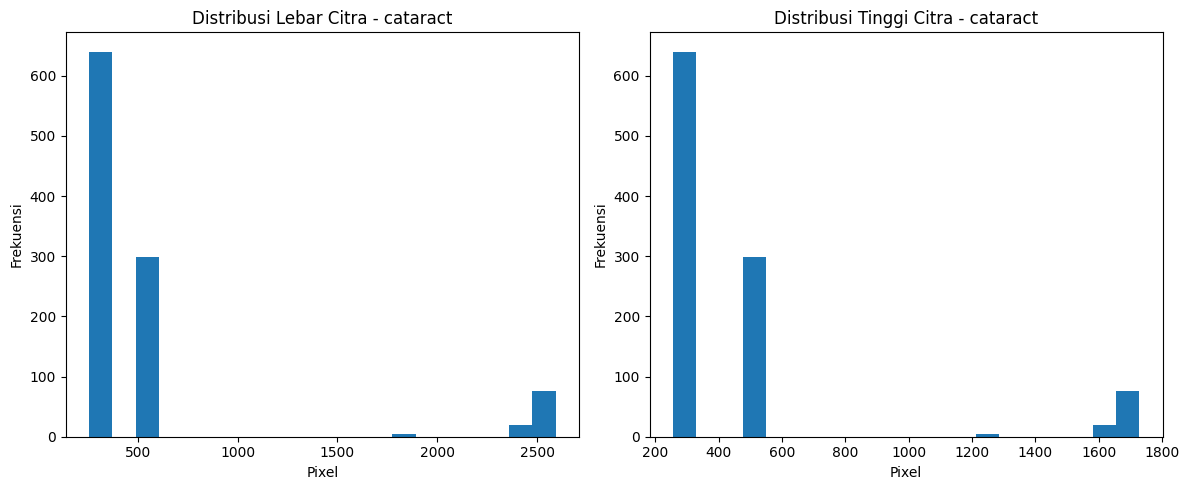

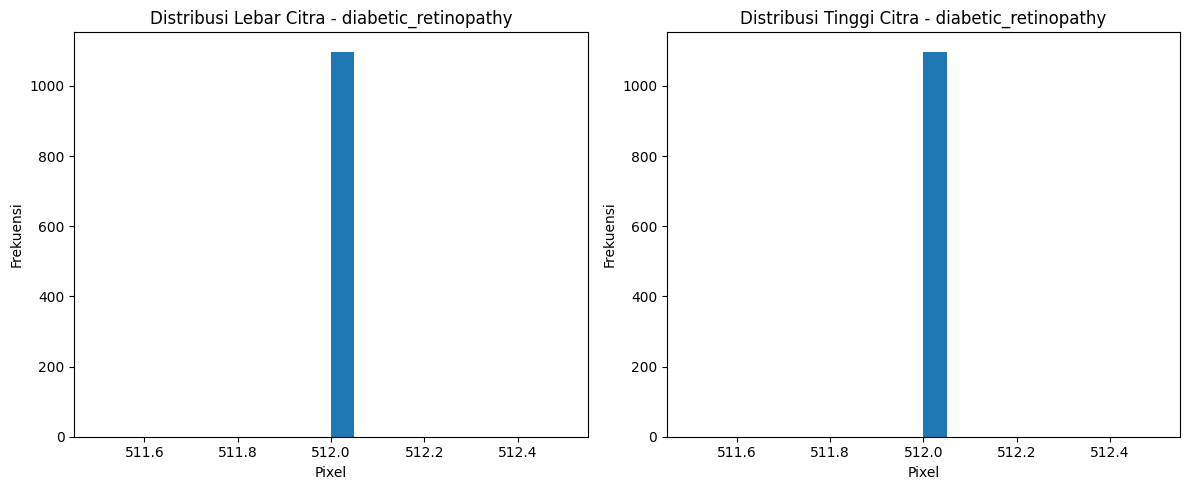

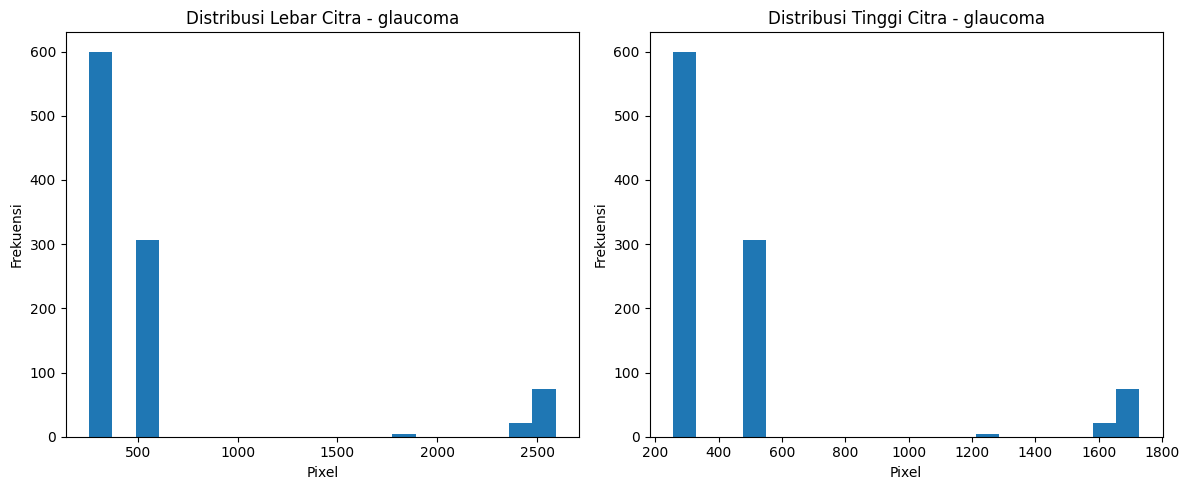

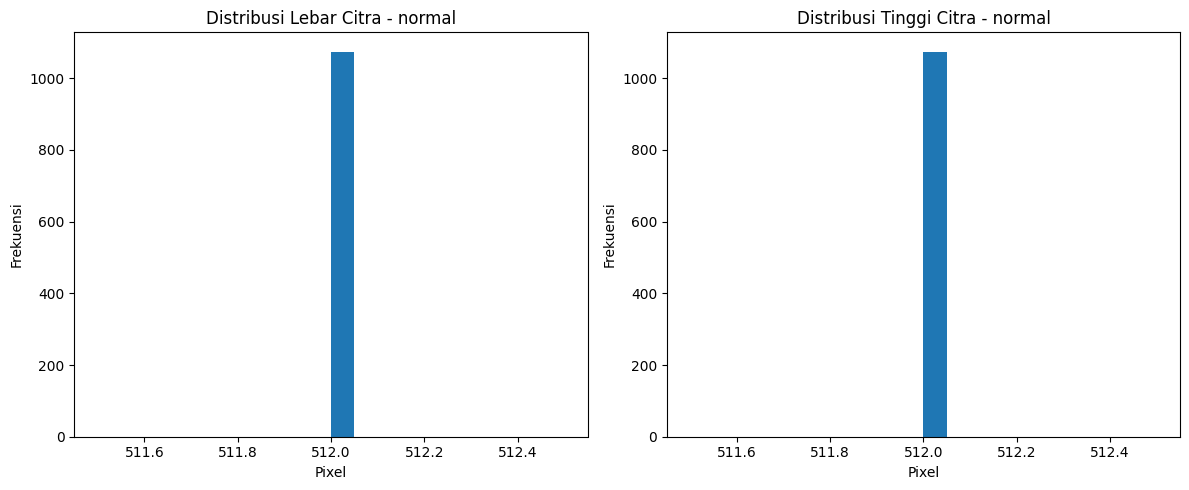

In [9]:
# Visualisasi distribusi lebar dan tinggi citra per kelas
import matplotlib.pyplot as plt

for cls in classes:
    subset = df_sizes[df_sizes["Class"] == cls]

    widths = subset["Width"]
    heights = subset["Height"]

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(widths, bins=20)
    plt.title(f"Distribusi Lebar Citra - {cls}")
    plt.xlabel("Pixel")
    plt.ylabel("Frekuensi")

    plt.subplot(1, 2, 2)
    plt.hist(heights, bins=20)
    plt.title(f"Distribusi Tinggi Citra - {cls}")
    plt.xlabel("Pixel")
    plt.ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()

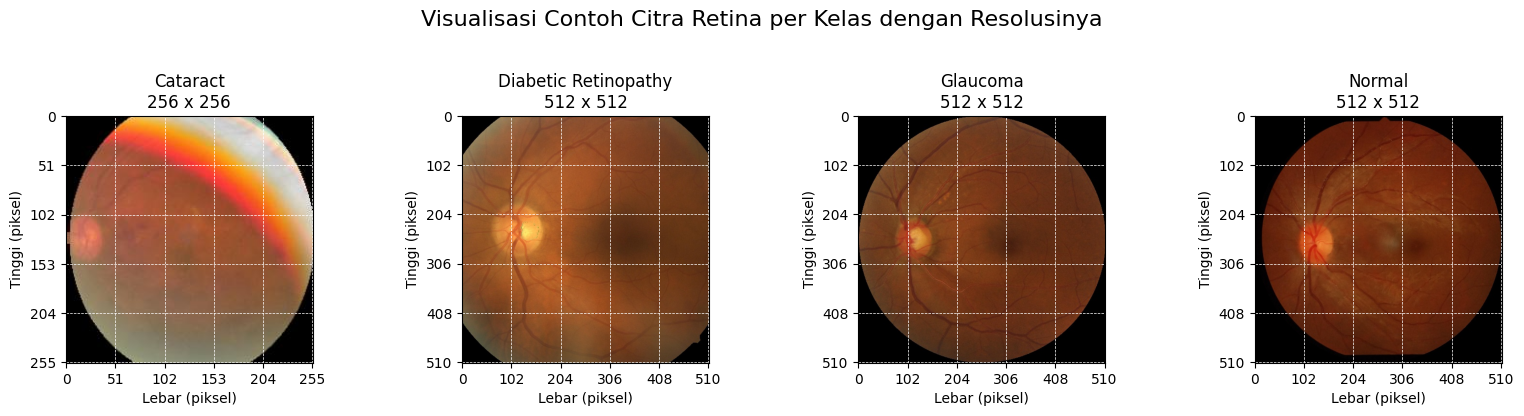

In [10]:
# Visualisasi Citra per Kelas + Grid Pixel + Axis
import random
from PIL import Image
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(16, 4))
plt.suptitle("Visualisasi Contoh Citra Retina per Kelas dengan Resolusinya", fontsize=16)

for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, cls)
    img_name = random.choice(os.listdir(cls_path))
    img_path = os.path.join(cls_path, img_name)

    img = Image.open(img_path)
    width, height = img.size

    ax = plt.subplot(1, 4, i+1)
    ax.imshow(img)

    # Judul + resolusi
    ax.set_title(f"{cls.replace('_', ' ').title()}\n{width} x {height}")

    # Tampilkan axis
    ax.set_xlabel("Lebar (piksel)")
    ax.set_ylabel("Tinggi (piksel)")

    # Aktifkan grid seperti contoh
    ax.set_xticks(range(0, width, max(width // 5, 1)))
    ax.set_yticks(range(0, height, max(height // 5, 1)))
    ax.grid(color='white', linestyle='--', linewidth=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

0it [00:00, ?it/s]
100%|█████████████████████████████████████████████████████████████████████████████| 1074/1074 [00:04<00:00, 233.39it/s]


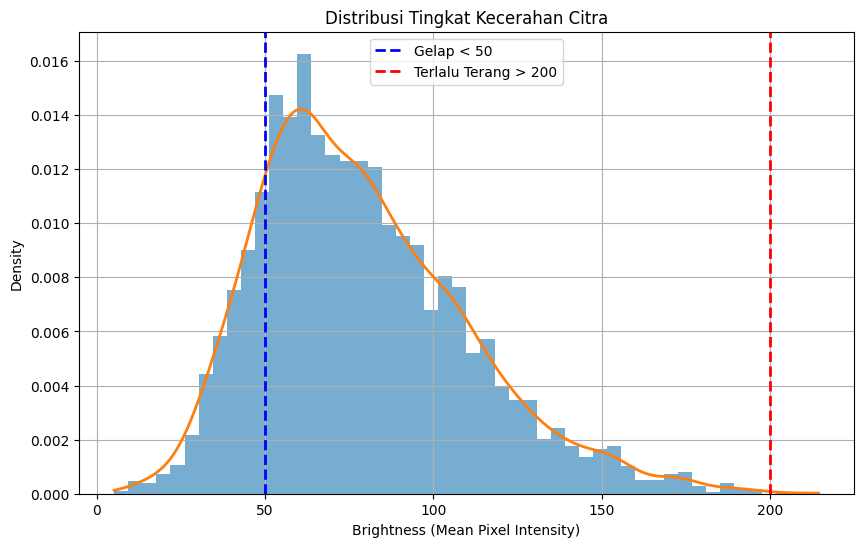

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import gaussian_kde

# =========================
# PARAMETER
# =========================
DATASET_DIR = r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset"

DARK_THRESHOLD = 50
BRIGHT_THRESHOLD = 200

# =========================
# SIMPAN NILAI KECERAHAN
# =========================
brightness_values = []

# =========================
# LOOP GAMBAR
# =========================
for root, dirs, files in os.walk(DATASET_DIR):
    for file in tqdm(files):
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):

            path = os.path.join(root, file)
            img = cv2.imread(path)

            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Hitung brightness (mean pixel)
            brightness = np.mean(gray)
            brightness_values.append(brightness)

# =========================
# KONVERSI
# =========================
brightness_values = np.array(brightness_values)

# =========================
# HISTOGRAM
# =========================
plt.figure(figsize=(10,6))
plt.hist(brightness_values, bins=50, density=True, alpha=0.6)

# =========================
# KDE CURVE
# =========================
kde = gaussian_kde(brightness_values)
x_range = np.linspace(brightness_values.min(), brightness_values.max(), 500)
plt.plot(x_range, kde(x_range), linewidth=2)

# =========================
# THRESHOLD
# =========================
plt.axvline(DARK_THRESHOLD, color='blue', linestyle='--', linewidth=2,
            label=f'Gelap < {DARK_THRESHOLD}')
plt.axvline(BRIGHT_THRESHOLD, color='red', linestyle='--', linewidth=2,
            label=f'Terlalu Terang > {BRIGHT_THRESHOLD}')

# =========================
# LABEL
# =========================
plt.title("Distribusi Tingkat Kecerahan Citra")
plt.xlabel("Brightness (Mean Pixel Intensity)")
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.show()

0it [00:00, ?it/s]
100%|█████████████████████████████████████████████████████████████████████████████| 1074/1074 [00:09<00:00, 107.70it/s]


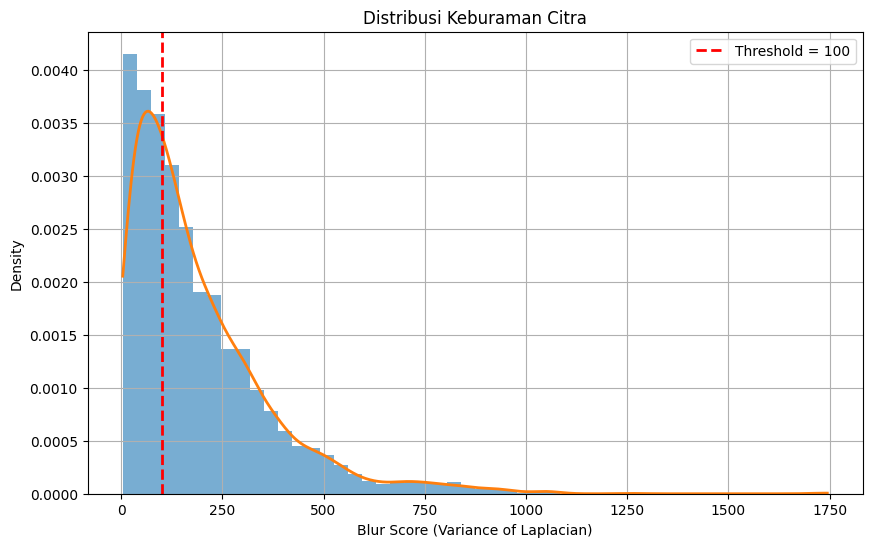

In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================
# PARAMETER
# =========================
DATASET_DIR = r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset"
BLUR_THRESHOLD = 100

# =========================
# SIMPAN NILAI BLUR
# =========================
blur_scores = []

# =========================
# LOOP GAMBAR
# =========================
for root, dirs, files in os.walk(DATASET_DIR):
    for file in tqdm(files):
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
            path = os.path.join(root, file)

            img = cv2.imread(path)
            if img is None:
                continue

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

            blur_scores.append(laplacian_var)

# =========================
# KONVERSI KE NUMPY
# =========================
blur_scores = np.array(blur_scores)

# =========================
# HISTOGRAM
# =========================
plt.figure(figsize=(10,6))
plt.hist(blur_scores, bins=50, density=True, alpha=0.6)

# =========================
# KDE (CURVE MELENGKUNG)
# =========================
from scipy.stats import gaussian_kde

kde = gaussian_kde(blur_scores)
x_range = np.linspace(blur_scores.min(), blur_scores.max(), 500)
plt.plot(x_range, kde(x_range), linewidth=2)

# =========================
# THRESHOLD (MERAH)
# =========================
plt.axvline(BLUR_THRESHOLD, color='red', linestyle='--', linewidth=2,
            label=f'Threshold = {BLUR_THRESHOLD}')

# =========================
# LABEL
# =========================
plt.title("Distribusi Keburaman Citra")
plt.xlabel("Blur Score (Variance of Laplacian)")
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.show()

In [18]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# =========================
# PARAMETER (SAMA DENGAN VISUALISASI)
# =========================
DATASET_DIR = r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset"

BLUR_THRESHOLD = 100
DARK_THRESHOLD = 50
BRIGHT_THRESHOLD = 200

# =========================
# INISIALISASI
# =========================
total_images = 0
blur_count = 0
dark_count = 0
bright_count = 0
corrupt_count = 0

# (Opsional: simpan file bermasalah)
blur_files = []
dark_files = []
bright_files = []
corrupt_files = []

# =========================
# LOOP DATASET
# =========================
for root, dirs, files in os.walk(DATASET_DIR):
    for file in tqdm(files):
        if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):

            total_images += 1
            path = os.path.join(root, file)

            try:
                img = cv2.imread(path)

                # =========================
                # CEK CITRA RUSAK
                # =========================
                if img is None:
                    corrupt_count += 1
                    corrupt_files.append(path)
                    continue

                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # =========================
                # CEK BLUR
                # =========================
                blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()
                if blur_score < BLUR_THRESHOLD:
                    blur_count += 1
                    blur_files.append(path)

                # =========================
                # CEK KECERAHAN
                # =========================
                brightness = np.mean(gray)

                if brightness < DARK_THRESHOLD:
                    dark_count += 1
                    dark_files.append(path)

                elif brightness > BRIGHT_THRESHOLD:
                    bright_count += 1
                    bright_files.append(path)

            except:
                corrupt_count += 1
                corrupt_files.append(path)

# =========================
# OUTPUT RINGKASAN
# =========================
print("\n===== RINGKASAN KUALITAS CITRA =====")
print(f"Total Citra           : {total_images}")
print(f"Citra Rusak           : {corrupt_count}")
print(f"Citra Blur            : {blur_count}")
print(f"Citra Terlalu Gelap   : {dark_count}")
print(f"Citra Terlalu Terang  : {bright_count}")

print("\n===== PERSENTASE =====")
print(f"Blur              : {blur_count/total_images*100:.2f}%")
print(f"Gelap             : {dark_count/total_images*100:.2f}%")
print(f"Terlalu Terang    : {bright_count/total_images*100:.2f}%")
print(f"Rusak             : {corrupt_count/total_images*100:.2f}%")

0it [00:00, ?it/s]
100%|██████████████████████████████████████████████████████████████████████████████| 1074/1074 [00:11<00:00, 90.72it/s]


===== RINGKASAN KUALITAS CITRA =====
Total Citra           : 4217
Citra Rusak           : 0
Citra Blur            : 1578
Citra Terlalu Gelap   : 712
Citra Terlalu Terang  : 2

===== PERSENTASE =====
Blur              : 37.42%
Gelap             : 16.88%
Terlalu Terang    : 0.05%
Rusak             : 0.00%


In [16]:
from torchvision import datasets, transforms

# Transformasi KHUSUS resize saja
resize_transform = transforms.Compose([
    transforms.Resize((224, 224))
])

# Load dataset dengan resize
dataset_resized = datasets.ImageFolder(
    root=dataset_path,
    transform=resize_transform
)

# Cek satu sampel
img_resized, label = dataset_resized[0]
print("Ukuran citra setelah resize:", img_resized.size)

Ukuran citra setelah resize: (224, 224)


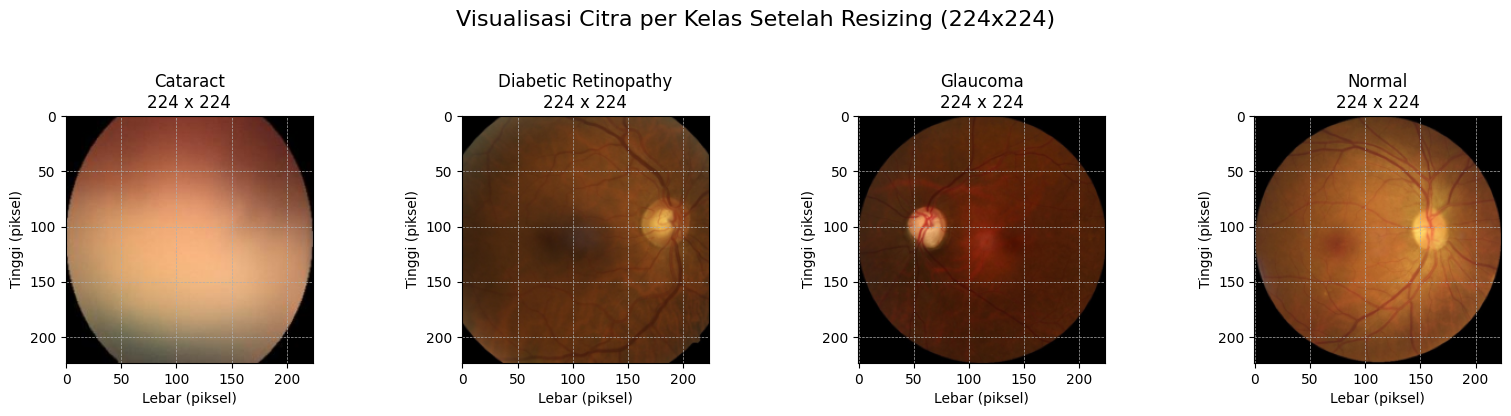

In [20]:
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(16, 4))
plt.suptitle("Visualisasi Citra per Kelas Setelah Resizing (224x224)", fontsize=16)

class_names = dataset_resized.classes

for i, cls in enumerate(class_names):
    # ambil sampel random per kelas
    idx = random.choice([j for j in range(len(dataset_resized)) if dataset_resized.targets[j] == i])
    img, label = dataset_resized[idx]

    ax = plt.subplot(1, len(class_names), i+1)
    ax.imshow(img)

    # Judul kelas + resolusi
    ax.set_title(f"{cls.replace('_',' ').title()}\n{img.size[0]} x {img.size[1]}")

    # Label axis
    ax.set_xlabel("Lebar (piksel)")
    ax.set_ylabel("Tinggi (piksel)")

    # Tambahkan ticks (biar seperti penggaris)
    ax.set_xticks(range(0, 225, 50))
    ax.set_yticks(range(0, 225, 50))

    # Grid
    ax.grid(True, linestyle='--', linewidth=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

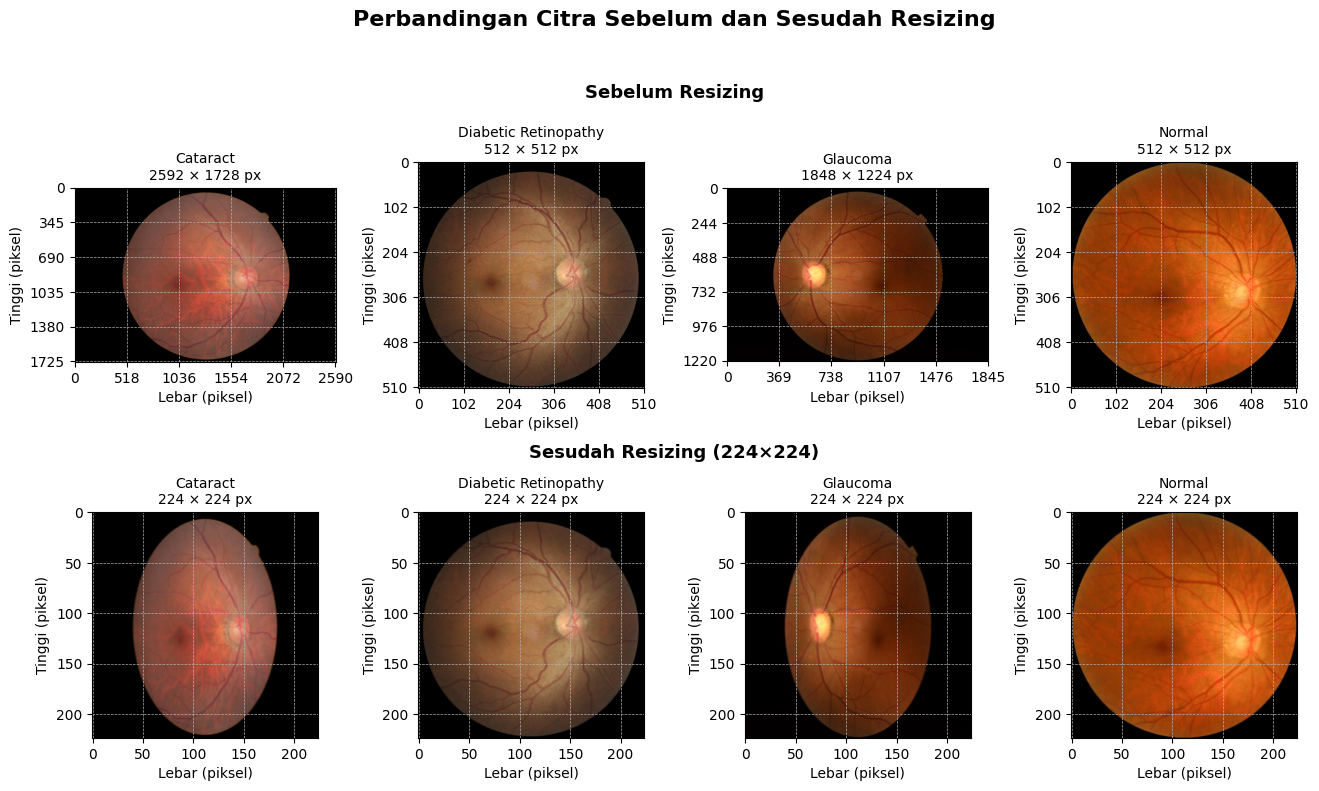

In [22]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms

image_paths = {
    "Cataract": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset\cataract\cataract_088.png",
    "Diabetic Retinopathy": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset\diabetic_retinopathy\11007_right.jpeg",
    "Glaucoma": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset\glaucoma\Glaucoma_069.png",
    "Normal": r"D:\REVA\skripsi\01. Dataset\01. Internal\dataset\normal\3438_right.jpg"
}

resize_transform = transforms.Resize((224, 224))

n_class = len(image_paths)
fig, axes = plt.subplots(2, n_class, figsize=(4*n_class, 8))

# =========================
# JUDUL UTAMA
# =========================
fig.suptitle("Perbandingan Citra Sebelum dan Sesudah Resizing",
             fontsize=16, weight='bold', y=0.97)

for i, (cls, path) in enumerate(image_paths.items()):
    
    img_original = Image.open(path).convert("RGB")
    img_resized = resize_transform(img_original)

    w_ori, h_ori = img_original.size
    w_res, h_res = img_resized.size

    # ===== SEBELUM =====
    ax1 = axes[0, i]
    ax1.imshow(img_original)
    ax1.set_title(f"{cls}\n{w_ori} × {h_ori} px", fontsize=10)
    ax1.set_xlabel("Lebar (piksel)")
    ax1.set_ylabel("Tinggi (piksel)")
    ax1.set_xticks(range(0, w_ori, max(w_ori//5,1)))
    ax1.set_yticks(range(0, h_ori, max(h_ori//5,1)))
    ax1.grid(True, linestyle='--', linewidth=0.5)

    # ===== SESUDAH =====
    ax2 = axes[1, i]
    ax2.imshow(img_resized)
    ax2.set_title(f"{cls}\n{w_res} × {h_res} px", fontsize=10)
    ax2.set_xlabel("Lebar (piksel)")
    ax2.set_ylabel("Tinggi (piksel)")
    ax2.set_xticks(range(0, 225, 50))
    ax2.set_yticks(range(0, 225, 50))
    ax2.grid(True, linestyle='--', linewidth=0.5)

# =========================
# ATUR LAYOUT (KRUSIAL)
# =========================
plt.subplots_adjust(
    top=0.78,     # kasih ruang header
    bottom=0.06,
    hspace=0.55,  # tambah jarak antar baris (INI KUNCI)
    wspace=0.25
)

# =========================
# JUDUL BARIS (FIX POSISI)
# =========================
fig.text(0.5, 0.86, "Sebelum Resizing",
         ha='center', fontsize=13, weight='bold')

fig.text(0.5, 0.41, "Sesudah Resizing (224×224)",
         ha='center', fontsize=13, weight='bold')

plt.show()

In [19]:
# Menyimpan Dataset Resize + Split Data ( 70% / 15% / 15% )
import os
import random
from torchvision import datasets, transforms
from PIL import Image
from tqdm import tqdm

# ===============================
# PATH
# ===============================
dataset_path = r"D:\REVA\skripsi\01. Dataset\dataset"
output_path = r"D:\REVA\skripsi\01. Dataset\dataset_resized_split_70_15_15"

# ===============================
# RASIO SPLIT
# ===============================
train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

# ===============================
# TRANSFORM RESIZE
# ===============================
resize_transform = transforms.Compose([
    transforms.Resize((224, 224))
])

# Load dataset
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=resize_transform
)

# Seed agar reproducible
random.seed(42)

# ===============================
# BUAT FOLDER OUTPUT
# ===============================
for split in ["train", "val", "test"]:
    for class_name in dataset.classes:
        os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

# ===============================
# PROSES PER KELAS
# ===============================
class_samples = {class_name: [] for class_name in dataset.classes}

# Kelompokkan index per kelas
for idx, (_, label) in enumerate(dataset.samples):
    class_name = dataset.classes[label]
    class_samples[class_name].append(idx)

# Split & simpan
for class_name, indices in class_samples.items():
    random.shuffle(indices)

    total = len(indices)
    train_end = int(total * train_ratio)
    val_end   = train_end + int(total * val_ratio)

    splits = {
        "train": indices[:train_end],
        "val":   indices[train_end:val_end],
        "test":  indices[val_end:]
    }

    for split, split_indices in splits.items():
        for idx in tqdm(split_indices, desc=f"{class_name} → {split}"):
            img, _ = dataset[idx]

            original_path, _ = dataset.samples[idx]
            filename = os.path.basename(original_path)

            save_path = os.path.join(output_path, split, class_name, filename)
            img.save(save_path)

normal → test: 100%|████████████████████████████████████████████████████████████████| 162/162 [00:01<00:00, 126.20it/s]


In [20]:
for split in ["train", "val", "test"]:
    total = 0
    for cls in os.listdir(os.path.join(output_path, split)):
        total += len(os.listdir(os.path.join(output_path, split, cls)))
    print(f"{split.upper()} : {total} citra")

TRAIN : 2949 citra
VAL : 631 citra
TEST : 637 citra


In [21]:
# Menyimpan Dataset Resize + Split Data ( 60% / 20% / 20% )
import os
import random
from torchvision import datasets, transforms
from PIL import Image
from tqdm import tqdm

# ===============================
# PATH
# ===============================
dataset_path = r"D:\REVA\skripsi\01. Dataset\dataset"
output_path = r"D:\REVA\skripsi\01. Dataset\dataset_resized_split_60_20_20"

# ===============================
# RASIO SPLIT
# ===============================
train_ratio = 0.60
val_ratio   = 0.20
test_ratio  = 0.20

# ===============================
# TRANSFORM RESIZE
# ===============================
resize_transform = transforms.Compose([
    transforms.Resize((224, 224))
])

# Load dataset
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=resize_transform
)

# Seed agar reproducible
random.seed(42)

# ===============================
# BUAT FOLDER OUTPUT
# ===============================
for split in ["train", "val", "test"]:
    for class_name in dataset.classes:
        os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

# ===============================
# PROSES PER KELAS
# ===============================
class_samples = {class_name: [] for class_name in dataset.classes}

# Kelompokkan index per kelas
for idx, (_, label) in enumerate(dataset.samples):
    class_name = dataset.classes[label]
    class_samples[class_name].append(idx)

# Split & simpan
for class_name, indices in class_samples.items():
    random.shuffle(indices)

    total = len(indices)
    train_end = int(total * train_ratio)
    val_end   = train_end + int(total * val_ratio)

    splits = {
        "train": indices[:train_end],
        "val":   indices[train_end:val_end],
        "test":  indices[val_end:]
    }

    for split, split_indices in splits.items():
        for idx in tqdm(split_indices, desc=f"{class_name} → {split}"):
            img, _ = dataset[idx]

            original_path, _ = dataset.samples[idx]
            filename = os.path.basename(original_path)

            save_path = os.path.join(output_path, split, class_name, filename)
            img.save(save_path)

normal → test: 100%|████████████████████████████████████████████████████████████████| 216/216 [00:01<00:00, 133.26it/s]


In [22]:
for split in ["train", "val", "test"]:
    total = 0
    for cls in os.listdir(os.path.join(output_path, split)):
        total += len(os.listdir(os.path.join(output_path, split, cls)))
    print(f"{split.upper()} : {total} citra")

TRAIN : 2528 citra
VAL : 841 citra
TEST : 848 citra


In [ ]:
# Menyimpan Dataset Resize + Split Data ( 80% / 10% / 10% )
import os
import random
from torchvision import datasets, transforms
from PIL import Image
from tqdm import tqdm

# ===============================
# PATH
# ===============================
dataset_path = r"D:\PERKULIAHAN\Bismillah Skripsi\01. Dataset\dataset"
output_path = r"D:\PERKULIAHAN\Bismillah Skripsi\01. Dataset\dataset_resized_split_80_10_10"

# ===============================
# RASIO SPLIT
# ===============================
train_ratio = 0.80
val_ratio   = 0.10
test_ratio  = 0.10

# ===============================
# TRANSFORM RESIZE
# ===============================
resize_transform = transforms.Compose([
    transforms.Resize((224, 224))
])

# Load dataset
dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=resize_transform
)

# Seed agar reproducible
random.seed(42)

# ===============================
# BUAT FOLDER OUTPUT
# ===============================
for split in ["train", "val", "test"]:
    for class_name in dataset.classes:
        os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

# ===============================
# PROSES PER KELAS
# ===============================
class_samples = {class_name: [] for class_name in dataset.classes}

# Kelompokkan index per kelas
for idx, (_, label) in enumerate(dataset.samples):
    class_name = dataset.classes[label]
    class_samples[class_name].append(idx)

# Split & simpan
for class_name, indices in class_samples.items():
    random.shuffle(indices)

    total = len(indices)
    train_end = int(total * train_ratio)
    val_end   = train_end + int(total * val_ratio)

    splits = {
        "train": indices[:train_end],
        "val":   indices[train_end:val_end],
        "test":  indices[val_end:]
    }

    for split, split_indices in splits.items():
        for idx in tqdm(split_indices, desc=f"{class_name} → {split}"):
            img, _ = dataset[idx]

            original_path, _ = dataset.samples[idx]
            filename = os.path.basename(original_path)

            save_path = os.path.join(output_path, split, class_name, filename)
            img.save(save_path)

normal → test: 100%|████████████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 216.45it/s]


In [ ]:
for split in ["train", "val", "test"]:
    total = 0
    for cls in os.listdir(os.path.join(output_path, split)):
        total += len(os.listdir(os.path.join(output_path, split, cls)))
    print(f"{split.upper()} : {total} citra")

TRAIN : 3372 citra
VAL : 419 citra
TEST : 426 citra
